In [1]:
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [2]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

data_files = glob.glob('data/spectra_data_100k*.pkl')
data_files = sorted(data_files)  # Ordena para garantizar un orden consistente

# Inicializar el diccionario donde se acumularán los datos
spectra_data = {}

# Cargar y combinar los datos de cada archivo encontrado
for file in data_files:
    with open(file, 'rb') as f:
        data_part = pickle.load(f)
    spectra_data.update(data_part)

print(f"Se han cargado {len(spectra_data)} espectros a partir de {len(data_files)} archivos.")

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelengths], axis=1)  # Ahora tiene 10000 características por muestra
y = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)

# scaler = StandardScaler()
# X = scaler.fit_transform(X)
# with open('extra/scaler_modelCNN_UPD4_100ktest.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

with open('extra/scaler_modelCNN_UPD4_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)
X = scaler.transform(X)

X = X.reshape(nsamples, nchannels, npoints)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

# Convertir a tensores de PyTorch y mover a GPU si está disponible
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Crear DataSets y DataLoaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

Usando dispositivo: cuda
Se han cargado 100000 espectros a partir de 10 archivos.


In [ ]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

scaler = StandardScaler()

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)

# Definir la función de pérdida
criterion = nn.MSELoss()

# Utilizar Adam con un weight decay para regularización L2
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)

# Scheduler adaptativo: ReduceLROnPlateau reduce la lr si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Usando dispositivo: cuda


In [4]:
# Entrenar el modelo
num_epochs = 99
for epoch in range(num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD4_100ktest.pth')

Epoch 1/99, Loss: 1.1409, Val Loss: 0.8742, LR: 0.0001000000
Epoch 2/99, Loss: 0.9288, Val Loss: 0.7832, LR: 0.0001000000
Epoch 3/99, Loss: 0.8134, Val Loss: 0.3202, LR: 0.0001000000
Epoch 4/99, Loss: 0.7423, Val Loss: 0.3370, LR: 0.0001000000
Epoch 5/99, Loss: 0.6992, Val Loss: 0.2557, LR: 0.0001000000
Epoch 6/99, Loss: 0.6623, Val Loss: 0.3420, LR: 0.0001000000
Epoch 7/99, Loss: 0.6378, Val Loss: 0.1518, LR: 0.0001000000
Epoch 8/99, Loss: 0.6094, Val Loss: 0.2152, LR: 0.0001000000
Epoch 9/99, Loss: 0.5872, Val Loss: 0.2451, LR: 0.0001000000
Epoch 10/99, Loss: 0.5654, Val Loss: 0.1809, LR: 0.0001000000
Epoch 11/99, Loss: 0.5528, Val Loss: 0.2819, LR: 0.0001000000
Epoch 12/99, Loss: 0.5317, Val Loss: 0.2244, LR: 0.0001000000
Epoch 13/99, Loss: 0.5200, Val Loss: 0.2425, LR: 0.0001000000
Epoch 14/99, Loss: 0.5029, Val Loss: 0.1417, LR: 0.0001000000
Epoch 15/99, Loss: 0.4886, Val Loss: 0.1889, LR: 0.0001000000
Epoch 16/99, Loss: 0.4736, Val Loss: 0.1128, LR: 0.0001000000
Epoch 17/99, Loss

In [ ]:
# Seguir entrenando el modelo
checkpoint = torch.load('storage/modelCNN_UPD4_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 200

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs + 1):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD4_100ktest.pth')






# Epoch 1/200, Loss: 1.1409, Val Loss: 0.8742, LR: 0.0001000000
# Epoch 2/200, Loss: 0.9288, Val Loss: 0.7832, LR: 0.0001000000
# Epoch 3/200, Loss: 0.8134, Val Loss: 0.3202, LR: 0.0001000000
# Epoch 4/200, Loss: 0.7423, Val Loss: 0.3370, LR: 0.0001000000
# Epoch 5/200, Loss: 0.6992, Val Loss: 0.2557, LR: 0.0001000000
# Epoch 6/200, Loss: 0.6623, Val Loss: 0.3420, LR: 0.0001000000
# Epoch 7/200, Loss: 0.6378, Val Loss: 0.1518, LR: 0.0001000000
# Epoch 8/200, Loss: 0.6094, Val Loss: 0.2152, LR: 0.0001000000
# Epoch 9/200, Loss: 0.5872, Val Loss: 0.2451, LR: 0.0001000000
# Epoch 10/200, Loss: 0.5654, Val Loss: 0.1809, LR: 0.0001000000
# Epoch 11/200, Loss: 0.5528, Val Loss: 0.2819, LR: 0.0001000000
# Epoch 12/200, Loss: 0.5317, Val Loss: 0.2244, LR: 0.0001000000
# Epoch 13/200, Loss: 0.5200, Val Loss: 0.2425, LR: 0.0001000000
# Epoch 14/200, Loss: 0.5029, Val Loss: 0.1417, LR: 0.0001000000
# Epoch 15/200, Loss: 0.4886, Val Loss: 0.1889, LR: 0.0001000000
# Epoch 16/200, Loss: 0.4736, Val Loss: 0.1128, LR: 0.0001000000
# Epoch 17/200, Loss: 0.4611, Val Loss: 0.0753, LR: 0.0001000000
# Epoch 18/200, Loss: 0.4472, Val Loss: 0.1229, LR: 0.0001000000
# Epoch 19/200, Loss: 0.4353, Val Loss: 0.0725, LR: 0.0001000000
# Epoch 20/200, Loss: 0.4286, Val Loss: 0.0665, LR: 0.0001000000
# Epoch 21/200, Loss: 0.4195, Val Loss: 0.0926, LR: 0.0001000000
# Epoch 22/200, Loss: 0.4136, Val Loss: 0.0100, LR: 0.0001000000
# Epoch 23/200, Loss: 0.3971, Val Loss: 0.0116, LR: 0.0001000000
# Epoch 24/200, Loss: 0.4004, Val Loss: 0.0396, LR: 0.0001000000
# Epoch 25/200, Loss: 0.3900, Val Loss: 0.0204, LR: 0.0001000000
# Epoch 26/200, Loss: 0.3873, Val Loss: 0.0647, LR: 0.0001000000
# Epoch 27/200, Loss: 0.3736, Val Loss: 0.0049, LR: 0.0001000000
# Epoch 28/200, Loss: 0.3731, Val Loss: 0.1091, LR: 0.0001000000
# Epoch 29/200, Loss: 0.3624, Val Loss: 0.0206, LR: 0.0001000000
# Epoch 30/200, Loss: 0.3552, Val Loss: 0.0146, LR: 0.0001000000
# Epoch 31/200, Loss: 0.3493, Val Loss: 0.0062, LR: 0.0001000000
# Epoch 32/200, Loss: 0.3399, Val Loss: 0.0309, LR: 0.0001000000
# Epoch 33/200, Loss: 0.3361, Val Loss: 0.0380, LR: 0.0001000000
# Epoch 34/200, Loss: 0.3245, Val Loss: 0.0067, LR: 0.0001000000
# Epoch 35/200, Loss: 0.3208, Val Loss: 0.0634, LR: 0.0001000000
# Epoch 36/200, Loss: 0.3102, Val Loss: 0.0441, LR: 0.0001000000
# Epoch 37/200, Loss: 0.2995, Val Loss: 0.0758, LR: 0.0001000000
# Epoch 38/200, Loss: 0.2998, Val Loss: 0.0001, LR: 0.0001000000
# Epoch 39/200, Loss: 0.2947, Val Loss: 0.0714, LR: 0.0001000000
# Epoch 40/200, Loss: 0.2895, Val Loss: 0.0410, LR: 0.0001000000
# Epoch 41/200, Loss: 0.2812, Val Loss: 0.0022, LR: 0.0001000000
# Epoch 42/200, Loss: 0.2766, Val Loss: 0.0612, LR: 0.0001000000
# Epoch 43/200, Loss: 0.2681, Val Loss: 0.1200, LR: 0.0001000000
# Epoch 44/200, Loss: 0.2621, Val Loss: 0.0068, LR: 0.0001000000
# Epoch 45/200, Loss: 0.2596, Val Loss: 0.0028, LR: 0.0001000000
# Epoch 46/200, Loss: 0.2502, Val Loss: 0.0931, LR: 0.0001000000
# Epoch 47/200, Loss: 0.2542, Val Loss: 0.0388, LR: 0.0001000000
# Epoch 48/200, Loss: 0.2427, Val Loss: 0.0846, LR: 0.0001000000
# Epoch 49/200, Loss: 0.2418, Val Loss: 0.0502, LR: 0.0000500000
# Epoch 50/200, Loss: 0.2118, Val Loss: 0.0391, LR: 0.0000500000
# Epoch 51/200, Loss: 0.2044, Val Loss: 0.0595, LR: 0.0000500000
# Epoch 52/200, Loss: 0.2070, Val Loss: 0.0333, LR: 0.0000500000
# Epoch 53/200, Loss: 0.1948, Val Loss: 0.0227, LR: 0.0000500000
# Epoch 54/200, Loss: 0.1935, Val Loss: 0.0145, LR: 0.0000500000
# Epoch 55/200, Loss: 0.1906, Val Loss: 0.0195, LR: 0.0000500000
# Epoch 56/200, Loss: 0.1883, Val Loss: 0.0531, LR: 0.0000500000
# Epoch 57/200, Loss: 0.1855, Val Loss: 0.0438, LR: 0.0000500000
# Epoch 58/200, Loss: 0.1823, Val Loss: 0.1166, LR: 0.0000500000
# Epoch 59/200, Loss: 0.1794, Val Loss: 0.0499, LR: 0.0000500000
# Epoch 60/200, Loss: 0.1759, Val Loss: 0.0281, LR: 0.0000250000
# Epoch 61/200, Loss: 0.1625, Val Loss: 0.0779, LR: 0.0000250000
# Epoch 62/200, Loss: 0.1605, Val Loss: 0.0768, LR: 0.0000250000
# Epoch 63/200, Loss: 0.1594, Val Loss: 0.0845, LR: 0.0000250000
# Epoch 64/200, Loss: 0.1586, Val Loss: 0.0387, LR: 0.0000250000
# Epoch 65/200, Loss: 0.1559, Val Loss: 0.0432, LR: 0.0000250000
# Epoch 66/200, Loss: 0.1533, Val Loss: 0.0306, LR: 0.0000250000
# Epoch 67/200, Loss: 0.1538, Val Loss: 0.0604, LR: 0.0000250000
# Epoch 68/200, Loss: 0.1494, Val Loss: 0.0391, LR: 0.0000250000
# Epoch 69/200, Loss: 0.1510, Val Loss: 0.0372, LR: 0.0000250000
# Epoch 70/200, Loss: 0.1519, Val Loss: 0.0227, LR: 0.0000250000
# Epoch 71/200, Loss: 0.1484, Val Loss: 0.0232, LR: 0.0000125000
# Epoch 72/200, Loss: 0.1422, Val Loss: 0.0215, LR: 0.0000125000
# Epoch 73/200, Loss: 0.1390, Val Loss: 0.0215, LR: 0.0000125000
# Epoch 74/200, Loss: 0.1389, Val Loss: 0.0382, LR: 0.0000125000
# Epoch 75/200, Loss: 0.1384, Val Loss: 0.0266, LR: 0.0000125000
# Epoch 76/200, Loss: 0.1368, Val Loss: 0.0386, LR: 0.0000125000
# Epoch 77/200, Loss: 0.1387, Val Loss: 0.0245, LR: 0.0000125000
# Epoch 78/200, Loss: 0.1370, Val Loss: 0.0308, LR: 0.0000125000
# Epoch 79/200, Loss: 0.1342, Val Loss: 0.0253, LR: 0.0000125000
# Epoch 80/200, Loss: 0.1337, Val Loss: 0.0274, LR: 0.0000125000
# Epoch 81/200, Loss: 0.1322, Val Loss: 0.0368, LR: 0.0000125000
# Epoch 82/200, Loss: 0.1342, Val Loss: 0.0303, LR: 0.0000062500
# Epoch 83/200, Loss: 0.1308, Val Loss: 0.0338, LR: 0.0000062500
# Epoch 84/200, Loss: 0.1308, Val Loss: 0.0355, LR: 0.0000062500
# Epoch 85/200, Loss: 0.1271, Val Loss: 0.0229, LR: 0.0000062500
# Epoch 86/200, Loss: 0.1280, Val Loss: 0.0286, LR: 0.0000062500
# Epoch 87/200, Loss: 0.1301, Val Loss: 0.0261, LR: 0.0000062500
# Epoch 88/200, Loss: 0.1282, Val Loss: 0.0255, LR: 0.0000062500
# Epoch 89/200, Loss: 0.1287, Val Loss: 0.0221, LR: 0.0000062500
# Epoch 90/200, Loss: 0.1260, Val Loss: 0.0258, LR: 0.0000062500
# Epoch 91/200, Loss: 0.1257, Val Loss: 0.0201, LR: 0.0000062500
# Epoch 92/200, Loss: 0.1263, Val Loss: 0.0345, LR: 0.0000062500
# Epoch 93/200, Loss: 0.1252, Val Loss: 0.0357, LR: 0.0000031250
# Epoch 94/200, Loss: 0.1226, Val Loss: 0.0305, LR: 0.0000031250
# Epoch 95/200, Loss: 0.1230, Val Loss: 0.0351, LR: 0.0000031250
# Epoch 96/200, Loss: 0.1273, Val Loss: 0.0221, LR: 0.0000031250
# Epoch 97/200, Loss: 0.1213, Val Loss: 0.0273, LR: 0.0000031250
# Epoch 98/200, Loss: 0.1229, Val Loss: 0.0313, LR: 0.0000031250
# Epoch 99/200, Loss: 0.1222, Val Loss: 0.0289, LR: 0.0000031250
# Epoch 100/200, Loss: 0.1224, Val Loss: 0.0326, LR: 0.0000031250
# Epoch 150/200, Loss: 0.1163, Val Loss: 0.0312, LR: 0.0000000977
# Epoch 200/200, Loss: 0.1177, Val Loss: 0.0301, LR: 0.0000000122

Epoch 100/200, Loss: 0.1224, Val Loss: 0.0326, LR: 0.0000031250
Epoch 150/200, Loss: 0.1163, Val Loss: 0.0312, LR: 0.0000000977
Epoch 200/200, Loss: 0.1177, Val Loss: 0.0301, LR: 0.0000000122
Error absoluto medio en el conjunto de prueba: 0.1735


Redshift real: 0.51303816
Redshift predicho: 0.4218812882900238


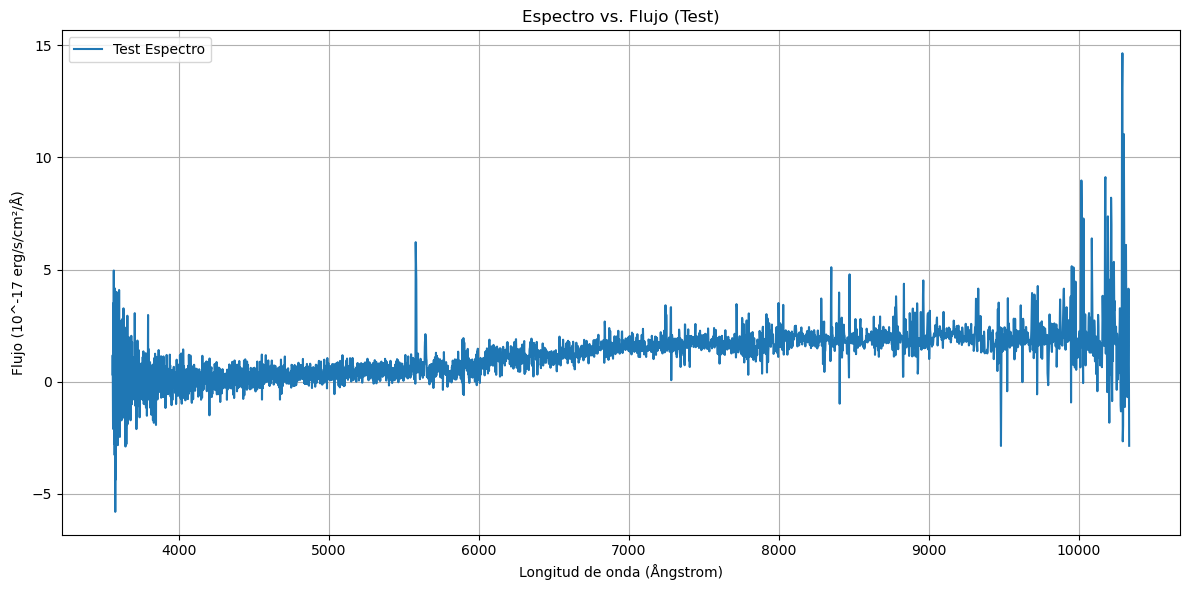

In [7]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

checkpoint = torch.load('storage/modelCNN_UPD4_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
with open('extra/scaler_modelCNN_UPD_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)


with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()